<a href="https://colab.research.google.com/github/shadcy/Menoetius-v7.1/blob/main/scan-time-paradigm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiment Goal

Show that: Full k-space --> clear mri
but,
For undersampled k-space --> Faster acquisition but artifacts appear

This exactly demonstrates why MRI reconstruction research exists

##Step 1: Load an MRI Image

(np.float64(-0.5), np.float64(450.5), np.float64(299.5), np.float64(-0.5))

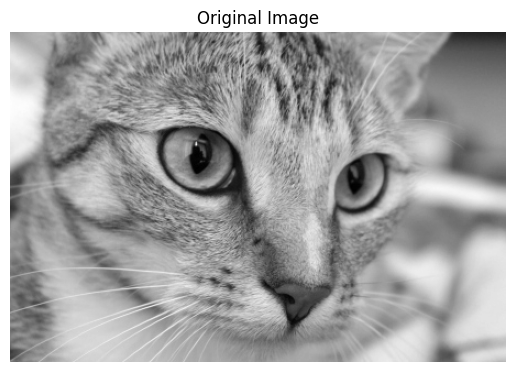

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

# Just an example....
img = color.rgb2gray(data.cat())

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

##Step 2: Convert Image to k-space

(np.float64(-0.5), np.float64(450.5), np.float64(299.5), np.float64(-0.5))

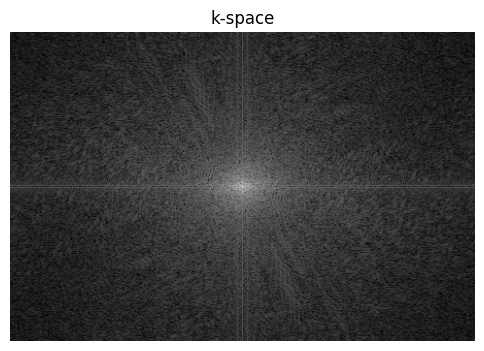

In [10]:
kspace = np.fft.fftshift(np.fft.fft2(img))
#The above line of code performs a 2D FFT on the image that we just loaded above,
#Then shifts zero freq components to the center

'''
This is the standared mathematical operation to convert a spatial domai image
(what we see) into k space (freq domain) used in MRI.
'''
plt.figure(figsize=(6,6))
plt.imshow(np.log(np.abs(kspace)+1), cmap='gray')
plt.title("k-space")
plt.axis("off")

##Interactive Undersampling

In [15]:
'''
In this piece of code, i wanted to explain how the image quality degrade when the reconstriction happens on
the x% where (0 <= x <= 100) of the k-space.
'''
from ipywidgets import interact

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)



'''
installing/importing the metrics, we'll be using to evaluate the quality of the reconstruction. from the orignal image
'''

"\ninstalling/importing the metrics, we'll be using to evaluate the quality of the reconstruction. from the orignal image\n"

In [16]:
@interact(sample_rate=(5,100,5))
def undersample(sample_rate=100):
    #Here we are trying to simulate the mask, why? cite: [cell 10]
    mask = np.zeros_like(kspace, dtype=float)

    rows = int(kspace.shape[0] * sample_rate / 100)

    center = kspace.shape[0] // 2
    start = center - rows // 2
    end = center + rows // 2

    mask[start:end, :] = 1

    # ----------------------------
    # Undersample k-space
    # ----------------------------
    sampled = kspace * mask

    # ----------------------------
    # Reconstruct image
    # ----------------------------
    recon = np.fft.ifft2(np.fft.ifftshift(sampled))
    recon = np.abs(recon)

    # Normalize reconstruction
    recon = (recon - recon.min()) / (recon.max() - recon.min())

    # ----------------------------
    # Metrics
    # ----------------------------
    mse = mean_squared_error(img, recon)
    rmse = np.sqrt(mse)

    psnr = peak_signal_noise_ratio(
        img,
        recon,
        data_range=1
    )

    ssim = structural_similarity(
        img,
        recon,
        data_range=1
    )

    # ----------------------------
    # Error Map
    # ----------------------------
    error = np.abs(img - recon)

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax = plt.subplots(1, 4, figsize=(20,5))

    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Original")

    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title(f"{sample_rate}% k-space")

    ax[2].imshow(recon, cmap='gray')
    ax[2].set_title("Reconstruction")

    im = ax[3].imshow(error, cmap='hot')
    ax[3].set_title("Error Map")

    for a in ax:
        a.axis("off")

    plt.colorbar(im, ax=ax[3], fraction=0.046)

    plt.suptitle(
        f"Sampling = {sample_rate}%    "
        f"PSNR = {psnr:.2f} dB    "
        f"SSIM = {ssim:.4f}    "
        f"RMSE = {rmse:.4f}",
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=100, description='sample_rate', min=5, step=5), Output()), _dom_classes=…